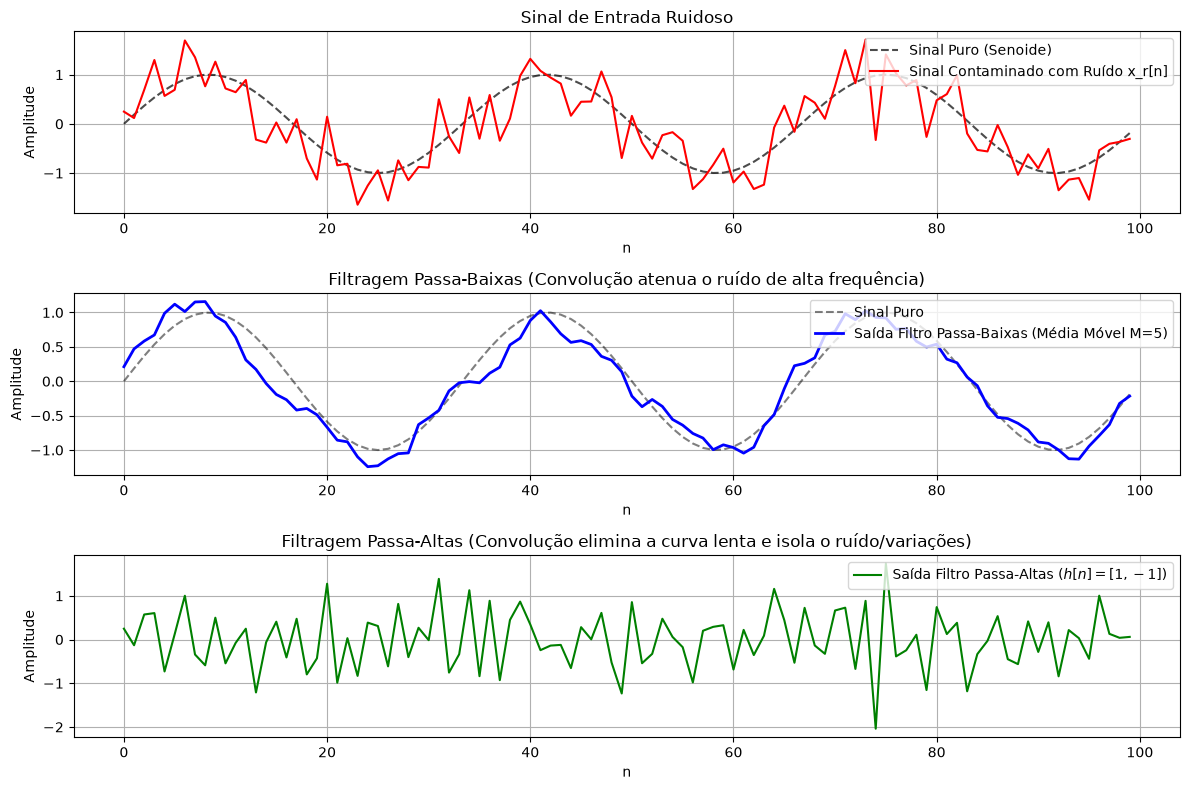

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Configuração do tempo discreto
N = 100
n = np.arange(0, N)

# 1. Sinal base (Senoide de baixa frequência) + Ruído aleatório de alta frequência
np.random.seed(42)
sinal_puro = np.sin(2 * np.pi * 0.03 * n)
ruido = 0.5 * np.random.randn(N)
x_ruidoso = sinal_puro + ruido

# 2. Resposta ao Impulso: Filtro Passa-Baixas (Média Móvel de 5 Pontos)
M = 5
h_pb = np.ones(M) / M

# 3. Resposta ao Impulso: Filtro Passa-Altas (Diferenciador {1, -1})
h_pa = np.array([1, -1])

# 4. Operação de Filtragem via Convolução
y_passa_baixas = np.convolve(x_ruidoso, h_pb, mode="same")
y_passa_altas = np.convolve(x_ruidoso, h_pa, mode="same")

# Plotagem dos Gráficos
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(n, sinal_puro, "k--", label="Sinal Puro (Senoide)", alpha=0.7)
plt.plot(n, x_ruidoso, "r-", label="Sinal Contaminado com Ruído x_r[n]")
plt.title("Sinal de Entrada Ruidoso")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc="upper right")

plt.subplot(3, 1, 2)
plt.plot(n, sinal_puro, "k--", label="Sinal Puro", alpha=0.5)
plt.plot(
    n,
    y_passa_baixas,
    "b-",
    linewidth=2,
    label="Saída Filtro Passa-Baixas (Média Móvel M=5)",
)
plt.title(
    "Filtragem Passa-Baixas (Convolução atenua o ruído de alta frequência)"
)
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc="upper right")

plt.subplot(3, 1, 3)
plt.plot(
    n,
    y_passa_altas,
    "g-",
    label=r"Saída Filtro Passa-Altas ($h[n] = [1, -1]$)",
)
plt.title(
    "Filtragem Passa-Altas (Convolução elimina a curva lenta e isola o ruído/variações)"
)
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()